# 06 — LUNA16 results aggregation

Single source of truth for every number that ends up in the paper. Loads per-fold JSON files written by notebooks 03–05 and produces:
- final mean ± std table (8 metrics × 5 models)
- aggregated out-of-fold ROC + PR curves
- confusion matrices (calibrated threshold)
- bar chart of metric means
- pairwise Wilcoxon p-values on per-fold AUC

Outputs land in `results/` (CSV) and `results/figures/` (PNG).

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    auc,
    average_precision_score,
)

from utils.training import load_fold_results
from utils.metrics import aggregate_folds, per_fold_metric_list
from utils.stats import format_results_table, pairwise_wilcoxon

with open('../configs/luna16.yaml') as f:
    cfg = yaml.safe_load(f)

results_dir = Path('..') / cfg['paths']['results']
figures_dir = Path('..') / cfg['paths']['figures']
figures_dir.mkdir(parents=True, exist_ok=True)

MODELS = ['SVM', 'RF', 'KNN', 'ResNet50_pretrained', 'ResNet50_scratch']
all_folds = {name: load_fold_results(results_dir / f'luna16_{name}.json') for name in MODELS}

In [3]:
# 1. Final metric table — calibrated threshold values.
agg = {name: aggregate_folds([f.metrics_calibrated for f in folds]) for name, folds in all_folds.items()}
table = format_results_table(agg)
table.to_csv(results_dir / 'luna16_summary_calibrated.csv')
table

,accuracy,sensitivity,specificity,precision,f1,balanced_accuracy,auc_roc,pr_auc
model,,,,,,,,
SVM,0.840 ± 0.292,0.852 ± 0.331,0.700 ± 0.447,0.975 ± 0.036,0.870 ± 0.256,0.776 ± 0.223,0.983 ± 0.024,0.999 ± 0.002
RF,0.984 ± 0.036,0.983 ± 0.039,1.000 ± 0.000,1.000 ± 0.000,0.991 ± 0.020,0.991 ± 0.019,0.996 ± 0.010,0.999 ± 0.002
KNN,0.911 ± 0.035,0.910 ± 0.056,0.900 ± 0.224,0.992 ± 0.019,0.948 ± 0.022,0.905 ± 0.087,0.980 ± 0.023,0.997 ± 0.003
ResNet50_pretrained,0.806 ± 0.115,0.874 ± 0.104,0.200 ± 0.274,0.906 ± 0.050,0.888 ± 0.072,0.537 ± 0.161,0.598 ± 0.129,0.942 ± 0.032
ResNet50_scratch,0.679 ± 0.260,0.670 ± 0.317,0.767 ± 0.325,0.972 ± 0.042,0.747 ± 0.266,0.718 ± 0.133,0.800 ± 0.088,0.974 ± 0.019


In [4]:
# Per-fold raw values — supplementary table demanded by the report (item 4).
rows = []
for name, folds in all_folds.items():
    for f in folds:
        row = {'model': name, 'fold': f.fold, **f.metrics_calibrated}
        rows.append(row)
per_fold_df = pd.DataFrame(rows)
per_fold_df.to_csv(results_dir / 'luna16_per_fold.csv', index=False)
per_fold_df

,model,fold,accuracy,sensitivity,specificity,precision,f1,balanced_accuracy,tp,tn,fp,fn,threshold,auc_roc,pr_auc
0,SVM,0,0.320000,0.260870,1.000000,1.000000,0.413793,0.630435,6,2,0,17,0.979090,0.956522,0.996522
1,SVM,1,0.920000,1.000000,0.000000,0.920000,0.958333,0.500000,23,0,2,0,0.337736,0.956522,0.996298
2,SVM,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,3,0,0,0.493281,1.000000,1.000000
3,SVM,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,3,0,0,0.703069,1.000000,1.000000
4,SVM,4,0.958333,1.000000,0.500000,0.956522,0.977778,0.750000,22,1,1,0,0.292199,1.000000,1.000000
5,RF,0,0.920000,0.913043,1.000000,1.000000,0.954545,0.956522,21,2,0,2,0.940000,0.978261,0.996377
6,RF,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,23,2,0,0,0.740000,1.000000,1.000000
7,RF,2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,3,0,0,0.354109,1.000000,1.000000
8,RF,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,3,0,0,0.695000,1.000000,1.000000
9,RF,4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,22,2,0,0,0.730000,1.000000,1.000000


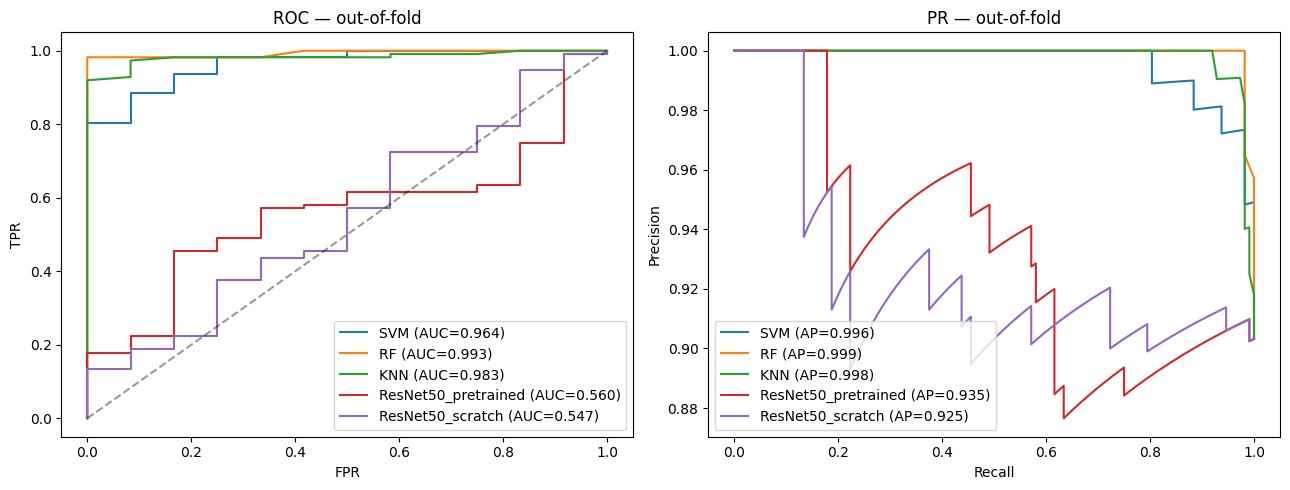

In [5]:
# 2. Aggregated out-of-fold ROC + PR curves.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for name, folds in all_folds.items():
    y_true = np.concatenate([np.array(f.y_true) for f in folds])
    y_proba = np.concatenate([np.array(f.y_proba) for f in folds])

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

    p, r, _ = precision_recall_curve(y_true, y_proba)
    axes[1].plot(r, p, label=f'{name} (AP={average_precision_score(y_true, y_proba):.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC — out-of-fold'); axes[0].legend()
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR — out-of-fold'); axes[1].legend()
plt.tight_layout(); plt.savefig(figures_dir / 'luna16_roc_pr.png', dpi=140); plt.show()

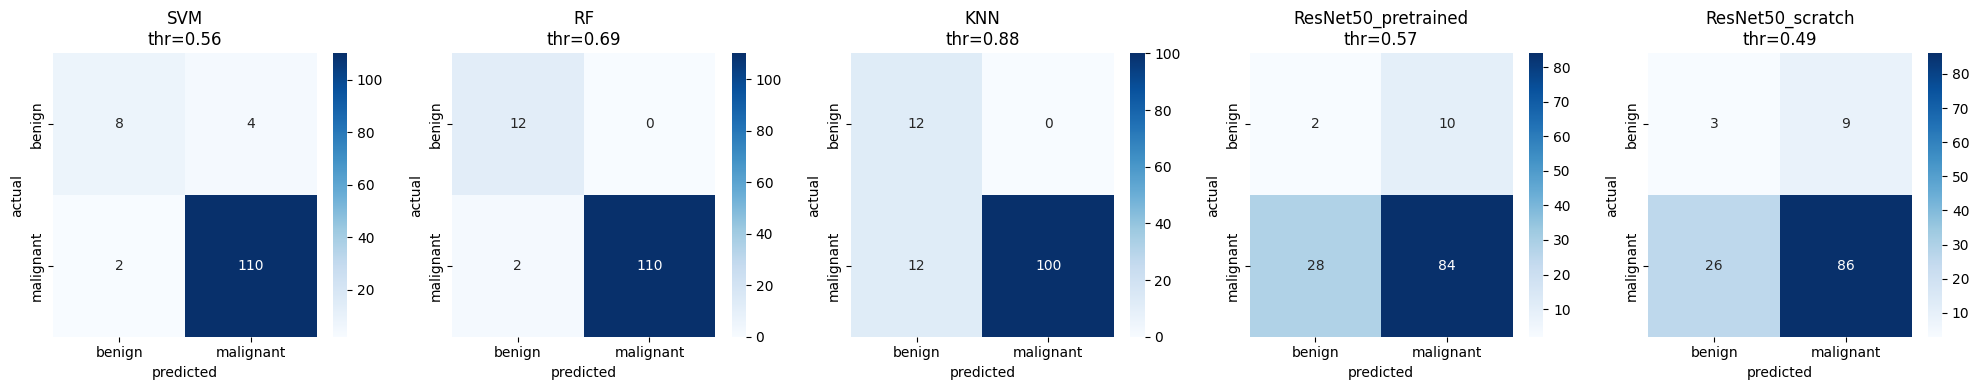

In [6]:
# 3. Confusion matrices at calibrated threshold (aggregated out-of-fold).
fig, axes = plt.subplots(1, len(MODELS), figsize=(4 * len(MODELS), 4))
for ax, (name, folds) in zip(axes, all_folds.items()):
    y_true = np.concatenate([np.array(f.y_true) for f in folds])
    y_proba = np.concatenate([np.array(f.y_proba) for f in folds])
    thr = float(np.mean([f.threshold_calibrated for f in folds]))
    y_pred = (y_proba >= thr).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['benign', 'malignant'], yticklabels=['benign', 'malignant'])
    ax.set_title(f'{name}\nthr={thr:.2f}'); ax.set_xlabel('predicted'); ax.set_ylabel('actual')
plt.tight_layout(); plt.savefig(figures_dir / 'luna16_confusion.png', dpi=140); plt.show()

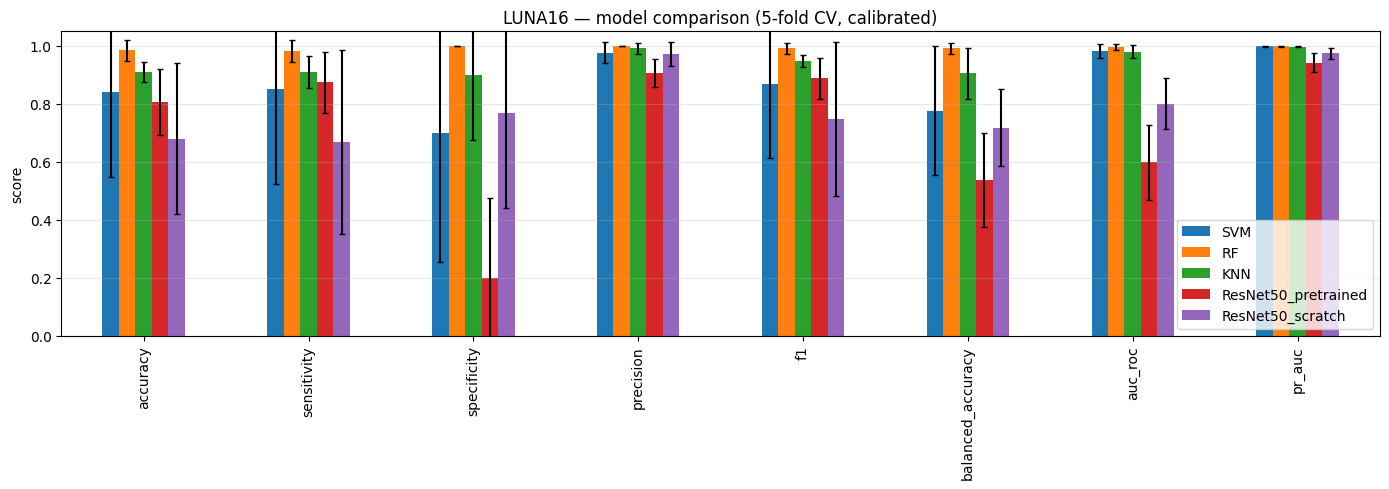

In [7]:
# 4. Bar chart of metric means (with std errorbars).
metrics = ['accuracy', 'sensitivity', 'specificity', 'precision', 'f1', 'balanced_accuracy', 'auc_roc', 'pr_auc']
means = pd.DataFrame({m: {name: agg[name][m]['mean'] for name in MODELS} for m in metrics})
stds = pd.DataFrame({m: {name: agg[name][m]['std'] for name in MODELS} for m in metrics})

ax = means.T.plot(kind='bar', yerr=stds.T, figsize=(14, 5), capsize=2)
ax.set_ylim(0, 1.05); ax.set_ylabel('score'); ax.set_title('LUNA16 — model comparison (5-fold CV, calibrated)')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.savefig(figures_dir / 'luna16_bars.png', dpi=140); plt.show()

In [8]:
# 5. Pairwise Wilcoxon on per-fold AUC (item 4 of the report).
auc_by_model = {name: per_fold_metric_list([f.metrics_calibrated for f in folds], 'auc_roc')
                for name, folds in all_folds.items()}
p_matrix = pairwise_wilcoxon(auc_by_model)
p_matrix.to_csv(results_dir / 'luna16_wilcoxon_auc.csv')
p_matrix

,SVM,RF,KNN,ResNet50_pretrained,ResNet50_scratch
SVM,1.0000,0.5000,1.0000,0.0625,0.0625
RF,0.5000,1.0000,0.2500,0.0625,0.0625
KNN,1.0000,0.2500,1.0000,0.0625,0.0625
ResNet50_pretrained,0.0625,0.0625,0.0625,1.0000,0.1250
ResNet50_scratch,0.0625,0.0625,0.0625,0.1250,1.0000


In [9]:
# 6. Transfer learning ablation summary: pretrained vs scratch.
pre = auc_by_model['ResNet50_pretrained']
scr = auc_by_model['ResNet50_scratch']
print('Pretrained AUC per fold:', [round(x, 3) for x in pre])
print('Scratch    AUC per fold:', [round(x, 3) for x in scr])
print(f'Pretrained mean ± std: {np.mean(pre):.3f} ± {np.std(pre, ddof=1):.3f}')
print(f'Scratch    mean ± std: {np.mean(scr):.3f} ± {np.std(scr, ddof=1):.3f}')
print(f'Wilcoxon p-value (paired): {p_matrix.loc["ResNet50_pretrained", "ResNet50_scratch"]:.4f}')

Pretrained AUC per fold: [0.609, 0.587, 0.742, 0.394, 0.659]
Scratch    AUC per fold: [0.848, 0.87, 0.652, 0.788, 0.841]
Pretrained mean ± std: 0.598 ± 0.129
Scratch    mean ± std: 0.800 ± 0.088
Wilcoxon p-value (paired): 0.1250
